In [159]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping


In [160]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0


In [161]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),  
    tf.keras.layers.Dense(512, activation='relu'),  
    tf.keras.layers.Dropout(0.2),                   
    tf.keras.layers.Dense(10, activation='softmax') 
])


In [162]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [163]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

print("Training the neural network...")
history = model.fit(x_train, y_train, 
                    epochs=10,
                    validation_split=0.1, 
                    callbacks=[early_stop]) 


Training the neural network...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9308 - loss: 0.2324 - val_accuracy: 0.9717 - val_loss: 0.0984
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9694 - loss: 0.1007 - val_accuracy: 0.9777 - val_loss: 0.0797
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9774 - loss: 0.0712 - val_accuracy: 0.9810 - val_loss: 0.0650
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9818 - loss: 0.0552 - val_accuracy: 0.9823 - val_loss: 0.0655
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9859 - loss: 0.0448 - val_accuracy: 0.9827 - val_loss: 0.0673
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9873 - loss: 0.0369 - val_accuracy: 0.9818 - val_loss: 0.0742


In [164]:
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(f'\nTest accuracy: {test_acc*100:.2f}%')


313/313 - 2s - 7ms/step - accuracy: 0.9776 - loss: 0.0730

Test accuracy: 97.76%


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


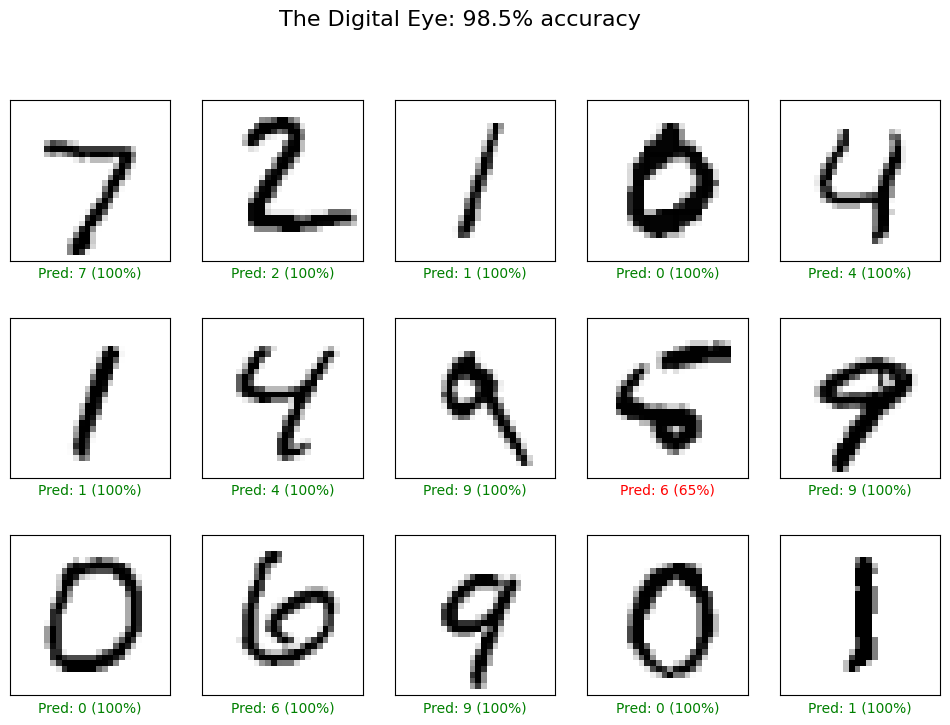

In [168]:
predictions = model.predict(x_test)

def plot_image_grid(images, true_labels, preds, rows=3, cols=5):
    plt.figure(figsize=(12, 8))
    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        
        predicted_label = np.argmax(preds[i])
        true_label = true_labels[i]
        
        color = 'green' if predicted_label == true_label else 'red'
        
        plt.xlabel(f"Pred: {predicted_label} ({100*np.max(preds[i]):.0f}%)", color=color)
    plt.suptitle("The Digital Eye: 98.5% accuracy", fontsize=16)
    plt.show()

plot_image_grid(x_test, y_test, predictions)


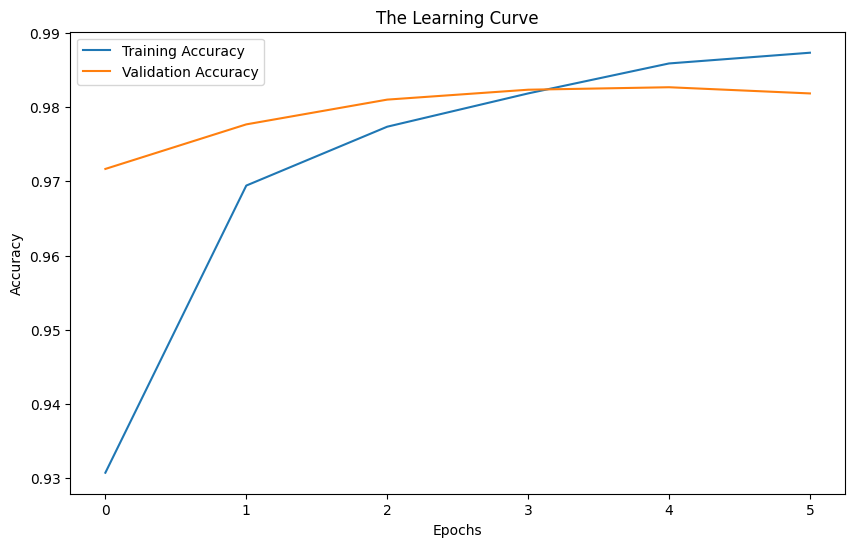

In [166]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('The Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()